### Dataset Info:
In IBM Cognos Analytics 11.1.3, the data module that is named Telco Customer Churn in the Base Samples was enhanced to provide a wider narrative.


The Telco customer churn data contains information about a fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3. It indicates which customers have left, stayed, or signed up for their service. Multiple important demographics are included for each customer, as well as a Satisfaction Score, Churn Score, and Customer Lifetime Value (CLTV) index.

##### Data Columns Descriptions
Demographics

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Gender: The customer’s gender: Male, Female

Age: The customer’s current age, in years, at the time the fiscal quarter ended.

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Married: Indicates if the customer is married: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Number of Dependents: Indicates the number of dependents that live with the customer.


Location


Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Lat Long: The combined latitude and longitude of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.


Population

Population: A current population estimate for the entire Zip Code area.

Services

Quarter: The fiscal quarter that the data has been derived from (e.g. Q3).

Referred a Friend: Indicates if the customer has ever referred a friend or family member to this company: Yes, No

Number of Referrals: Indicates the number of referrals to date that the customer has made.

Tenure in Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Offer: Identifies the last marketing offer that the customer accepted, if applicable. Values include None, Offer A, Offer B, Offer C, Offer D, and Offer E.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Avg Monthly Long Distance Charges: Indicates the customer’s average long distance charges, calculated to the end of the quarter specified above.

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Avg Monthly GB Download: Indicates the customer’s average download volume in gigabytes, calculated to the end of the quarter specified above.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection Plan: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Premium Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Music: Indicates if the customer uses their Internet service to stream music from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Unlimited Data: Indicates if the customer has paid an additional monthly fee to have unlimited data downloads/uploads: Yes, No

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Total Refunds: Indicates the customer’s total refunds, calculated to the end of the quarter specified above.

Total Extra Data Charges: Indicates the customer’s total charges for extra data downloads above those specified in their plan, by the end of the quarter specified above.

Total Long Distance Charges: Indicates the customer’s total charges for long distance above those specified in their plan, by the end of the quarter specified above.


Status

Satisfaction Score: A customer’s overall satisfaction rating of the company from 1 (Very Unsatisfied) to 5 (Very Satisfied).

Satisfaction Score Label: Indicates the text version of the score (1-5) as a text string.

Customer Status: Indicates the status of the customer at the end of the quarter: Churned, Stayed, or Joined

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

Churn Score Category: A calculation that assigns a Churn Score to one of the following categories: 0-10, 11-20, 21-30, 31-40, 41-50, 51-60, 61-70, 71-80, 81-90, and 91-100

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

CLTV Category: A calculation that assigns a CLTV value to one of the following categories: 2000-2500, 2501-3000, 3001-3500, 3501-4000, 4001-4500, 4501-5000, 5001-5500, 5501-6000, 6001-6500, and 6501-7000.

Churn Category: A high-level category for the customer’s reason for churning: Attitude, Competitor, Dissatisfaction, Other, Price. When they leave the company, all customers are asked about their reasons for leaving. Directly related to Churn Reason.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.

Any Additional Information :

### Downloading Dataset

In [1]:
# !pip install optuna # For hyperparameter training later on

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")

print("Path to dataset files:", path)

100%|██████████| 513k/513k [00:00<00:00, 102MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1


In [3]:
import pandas as pd
df = pd.read_csv('/root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1/telco.csv')

### Some Primary Assessments

In [4]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [5]:
df.tail()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN
7042,3186-AJIEK,Male,44,No,No,No,No,0,United States,California,...,0,2043.36,8887.86,4,Stayed,No,38,5097,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [7]:
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].unique()}")

Unique values in 'Customer ID': ['8779-QRDMV' '7495-OOKFY' '1658-BYGOY' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Unique values in 'Gender': ['Male' 'Female']
Unique values in 'Age': [78 74 71 80 72 76 66 70 77 65 67 68 69 79 75 73 37 19 31 23 38 21 29 61
 27 20 56 51 48 32 34 41 30 26 62 64 45 53 63 42 24 54 39 43 50 22 40 47
 60 52 55 59 49 58 25 28 33 44 57 46 36 35]
Unique values in 'Under 30': ['No' 'Yes']
Unique values in 'Senior Citizen': ['Yes' 'No']
Unique values in 'Married': ['No' 'Yes']
Unique values in 'Dependents': ['No' 'Yes']
Unique values in 'Number of Dependents': [0 1 3 2 5 4 6 7 8 9]
Unique values in 'Country': ['United States']
Unique values in 'State': ['California']
Unique values in 'City': ['Los Angeles' 'Inglewood' 'Whittier' ... 'Topaz' 'Jacumba' 'Holtville']
Unique values in 'Zip Code': [90022 90063 90065 ... 91934 92105 92250]
Unique values in 'Latitude': [34.02381  34.044271 34.108833 ... 32.649787 32.741859 32.811001]
Unique values in 'Longitude': [-118

In [8]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [9]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


##### After Manual Assement:
1. The Country and State column can be dropped, cause all the customers are from California, United States
2. the Quarter Column is also Constant
3. Churn Reasons and Categories are missing

#### Issues with the dataset
1. Dirty Data:
    1. Churn Reason and Churn Category have missing Values
    2. Internet Type and Offer have missing values that should be filled
  
2. Messy Data


#### Work to do:
1. Drop Cusotmer ID and City column, cause they have too many categories, also Drop Churn Score and Customer Status column (preventing leakage)
2. Gender, under30, senior citezen, married, dependents,refer to friend, phone service, multiple lines, internet service,Online Security,Online Backup,Device Protection Plan,Premium Tech Support, Streaming TV, Streaming Movies, Streaming Music, Unlimited Data, Paperless Billing, Churn Label should be converted have binary incoding
3. Offer, Internet type, Contract, Payment Menthod, Customer Status should be One-hot encoded

### Cleaning and Encoding

In [10]:
def preprocess_telco(df):

  df.drop(columns=['Customer ID', 'Country', 'State', 'City', 'Quarter', 'Customer Status','Churn Score' ], axis = 1, inplace=True, ) # Dropping columns wiht too many category

  df['Offer'] = df['Offer'].fillna('No Offer') # Filling missing values

  df['Internet Type'] = df['Internet Type'].fillna('No Internet') # Filling missing values

#Binary encoding
  binary_cols = [
    'Gender',
    'Under 30',
    'Senior Citizen',
    'Married',
    'Dependents',
    'Referred a Friend',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data',
    'Paperless Billing',
    'Churn Label'
    ]

# Binary encoding Yes/no Columns
  yes_no_cols = [
      'Under 30',
      'Senior Citizen',
      'Married',
      'Dependents',
      'Referred a Friend',
      'Phone Service',
      'Multiple Lines',
      'Internet Service',
      'Online Security',
      'Online Backup',
      'Device Protection Plan',
      'Premium Tech Support',
      'Streaming TV',
      'Streaming Movies',
      'Streaming Music',
      'Unlimited Data',
      'Paperless Billing',
      'Churn Label'
  ]

  df['Gender'] = df['Gender'].map({ # Encoding Gender Columns
    'Male': 0,
    'Female': 1 })

  one_hot_cols = [
    'Offer',
    'Internet Type',
    'Contract',
    'Payment Method']
  for col in binary_cols: # Checking
    print(col)
    print(df[col].unique())

  for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

  df.drop(columns = ['Churn Category','Churn Reason' ], axis = 1, inplace =True) # This is added after observing corr matrix


In [11]:
preprocess_telco(df)

Gender
[0 1]
Under 30
['No' 'Yes']
Senior Citizen
['Yes' 'No']
Married
['No' 'Yes']
Dependents
['No' 'Yes']
Referred a Friend
['No' 'Yes']
Phone Service
['No' 'Yes']
Multiple Lines
['No' 'Yes']
Internet Service
['Yes' 'No']
Online Security
['No' 'Yes']
Online Backup
['No' 'Yes']
Device Protection Plan
['Yes' 'No']
Premium Tech Support
['No' 'Yes']
Streaming TV
['No' 'Yes']
Streaming Movies
['Yes' 'No']
Streaming Music
['No' 'Yes']
Unlimited Data
['No' 'Yes']
Paperless Billing
['Yes' 'No']
Churn Label
['Yes' 'No']


In [12]:
# Creating test set prior

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Churn Label'])



In [13]:
from sklearn.preprocessing import OneHotEncoder
one_hot_cols = ['Offer', 'Internet Type', 'Contract', 'Payment Method']
encoder = OneHotEncoder(
    sparse_output=False,
    )
encoded = encoder.fit_transform(train_set[one_hot_cols])
# Converting back array to df
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(one_hot_cols), index = train_set.index)

In [14]:
## Dropping original columns and join encoded columns
df_tr = train_set.drop(columns=one_hot_cols)
df_tr = pd.concat([df_tr, encoded_df], axis=1)

In [15]:
df_tr['Churn Label'].value_counts()

,count
Churn Label,
0,4139
1,1495


Total charges, total long distance charges, total revenue and population are right tailed and label distribution aren't that bad : 0->5174
1->1869



### Visualizing Correlation

In [16]:
# Create Corr Matrix and Drop Highly Corr features
# Count Feature Importance and Plot it
# Normalize (in tree based models normalization isn't needed)
# Train 3 Models you think are the best (Decision Tree, Random Forest, XGB, LightGBM, Adaboost)
# Tune

In [17]:
corr = df_tr.corr(numeric_only=True)
corr['Churn Label'].sort_values(ascending=False)
#

,Churn Label
Churn Label,1.000000
Contract_Month-to-Month,0.454030
Internet Type_Fiber Optic,0.283089
Internet Service,0.226572
Offer_Offer E,0.209255
Paperless Billing,0.195768
Monthly Charge,0.190421
Payment Method_Bank Withdrawal,0.189275
Unlimited Data,0.164676
Senior Citizen,0.141784


In [18]:
df_test = test_set

In [19]:
ytrain = df_tr['Churn Label']
Xtrain = df_tr.drop('Churn Label', axis=1)
ytest = df_test['Churn Label']
Xtest = df_test.drop('Churn Label', axis = 1)

In [20]:
Xtrain.info(

)

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 4626 to 6017
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             5634 non-null   int64  
 1   Age                                5634 non-null   int64  
 2   Under 30                           5634 non-null   int64  
 3   Senior Citizen                     5634 non-null   int64  
 4   Married                            5634 non-null   int64  
 5   Dependents                         5634 non-null   int64  
 6   Number of Dependents               5634 non-null   int64  
 7   Zip Code                           5634 non-null   int64  
 8   Latitude                           5634 non-null   float64
 9   Longitude                          5634 non-null   float64
 10  Population                         5634 non-null   int64  
 11  Referred a Friend                  5634 non-null   int64  

In [21]:
ytrain

,Churn Label
4626,0
4192,0
5457,0
4717,0
4673,0
...,...
6507,0
2312,1
1888,1
3870,0


### Feature Importance

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(Xtrain, ytrain)

RandomForestClassifier()

In [23]:
importance = rf.feature_importances_
importance

array([0.00254103, 0.02145306, 0.00163833, 0.00701472, 0.00294486,
       0.00870669, 0.01064618, 0.01726576, 0.01749353, 0.01539919,
       0.01597865, 0.00363483, 0.03474244, 0.03920669, 0.00097642,
       0.01500264, 0.00295766, 0.00684351, 0.01842803, 0.00802831,
       0.00233446, 0.00196377, 0.00519368, 0.00240177, 0.00212794,
       0.00383214, 0.00273698, 0.0054714 , 0.03136705, 0.02766098,
       0.00271418, 0.00321664, 0.02194937, 0.02740663, 0.45442131,
       0.01614294, 0.0026283 , 0.00057275, 0.00121757, 0.00078467,
       0.00135558, 0.00393592, 0.00112401, 0.00380559, 0.01820343,
       0.00523039, 0.04696821, 0.00977275, 0.02988026, 0.00340091,
       0.00753467, 0.0017412 ])

In [24]:
feature_imp = pd.DataFrame({
    'Feature': Xtrain.columns,
    'Importance': importance}
)
feature_imp.sort_values(by='Importance', ascending=False)


,Feature,Importance
34,Satisfaction Score,0.454421
46,Contract_Month-to-Month,0.046968
13,Tenure in Months,0.039207
12,Number of Referrals,0.034742
28,Monthly Charge,0.031367
48,Contract_Two Year,0.029880
29,Total Charges,0.027661
33,Total Revenue,0.027407
32,Total Long Distance Charges,0.021949
1,Age,0.021453


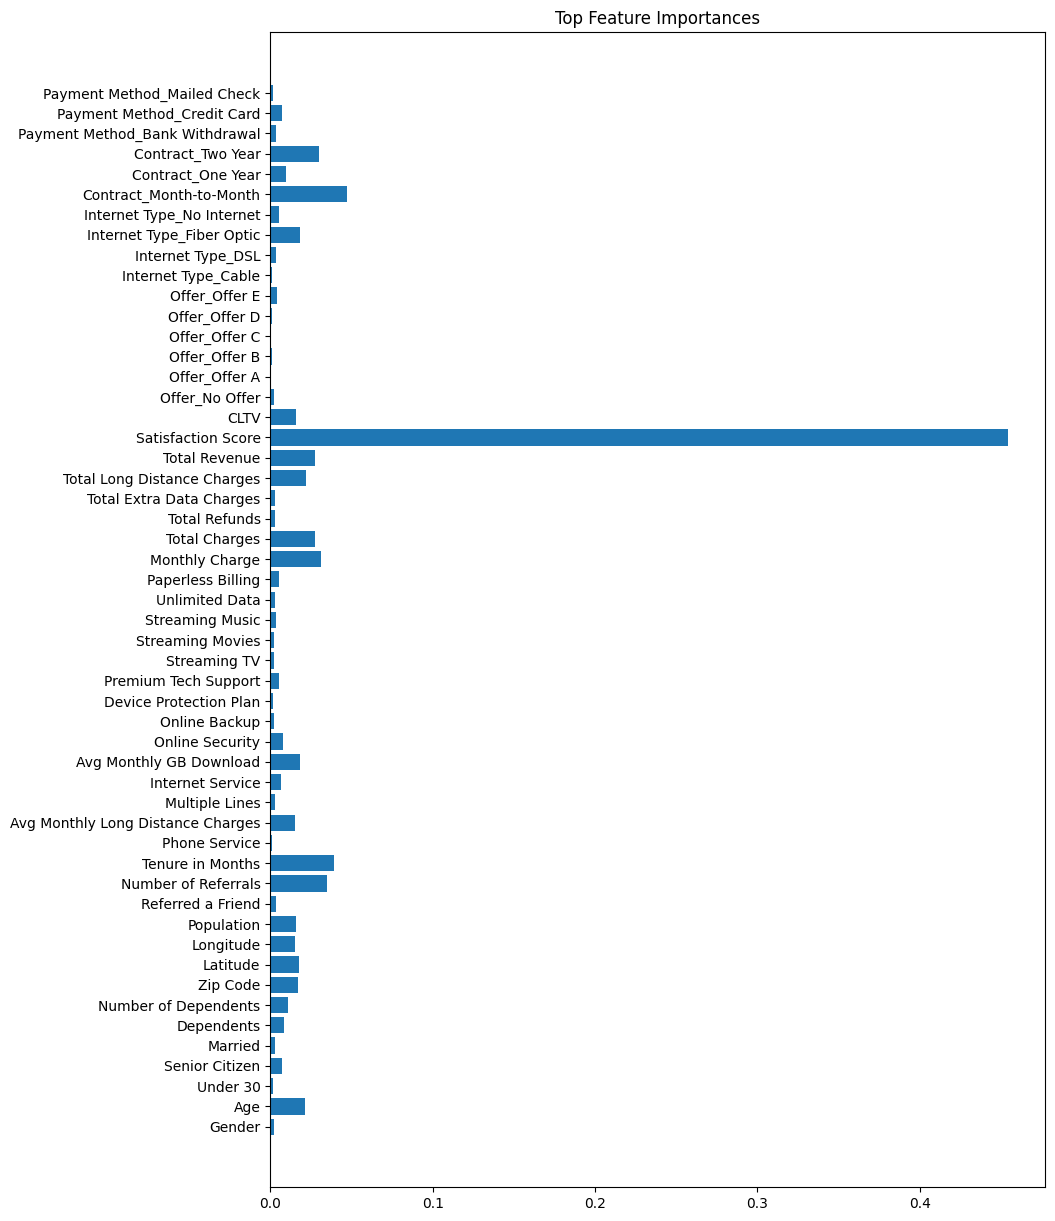

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize =(10, 15
                     ))

plt.barh(
  feature_imp['Feature'],
  feature_imp['Importance']
)
plt.title('Top Feature Importances')
plt.show()

In [26]:
print(Xtrain.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 4626 to 6017
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             5634 non-null   int64  
 1   Age                                5634 non-null   int64  
 2   Under 30                           5634 non-null   int64  
 3   Senior Citizen                     5634 non-null   int64  
 4   Married                            5634 non-null   int64  
 5   Dependents                         5634 non-null   int64  
 6   Number of Dependents               5634 non-null   int64  
 7   Zip Code                           5634 non-null   int64  
 8   Latitude                           5634 non-null   float64
 9   Longitude                          5634 non-null   float64
 10  Population                         5634 non-null   int64  
 11  Referred a Friend                  5634 non-null   int64  

### Model Definition And Training

Always stratify for churn datasets.

In [27]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth= 7,
    random_state=42
)


In [28]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state = 42,
    n_jobs= -1

)


In [29]:
from sklearn.ensemble import AdaBoostClassifier
ad = AdaBoostClassifier(
    n_estimators=200,
    learning_rate = 0.05,
    random_state=42
)


In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    n_jobs= -1
)


In [31]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs= -1
)


In [32]:
import time
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'AdaBoost': ad,
    'XGBoost': xgb,
    'LightGBM': lgbm
}

for name, model in models.items():
  start_time = time.time()
  model.fit(Xtrain, ytrain)
  end_time = time.time() - start_time
  print(f'Training Time: {end_time}')
  print(f'{name} trained successfully')


Training Time: 0.07454276084899902
Decision Tree trained successfully
Training Time: 1.2954764366149902
Random Forest trained successfully
Training Time: 2.566241979598999
AdaBoost trained successfully
Training Time: 1.1113672256469727
XGBoost trained successfully
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2988
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Training Time: 0.4273838996887207
LightGBM trained successfully


In [33]:
from sklearn.model_selection import cross_val_score
import pandas as pd

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        Xtrain,
        ytrain,
        cv=5,
        scoring='f1'
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Mean F1', 'Std']
)

results_df.sort_values(
    'Mean F1',
    ascending=False
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2959
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wi

,Model,Mean F1,Std
3,XGBoost,0.930719,0.010701
4,LightGBM,0.927163,0.011090
1,Random Forest,0.901314,0.021117
0,Decision Tree,0.900557,0.012533
2,AdaBoost,0.871465,0.016077


### HyperParameter Tuning


In [34]:
scale_pos_weight = (ytrain == 0).sum() / (ytrain == 1).sum()
scale_pos_weight

np.float64(2.768561872909699)

In [35]:
import time
from sklearn.model_selection import GridSearchCV
clfx = GridSearchCV(XGBClassifier(random_state = 42, eval_metric = 'logloss'), {
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.02, 0.001, 0.05],
    'scale_pos_weight': [1, 2.7],
}, cv=5, scoring='f1', return_train_score=False)
start_time = time.time()
clfx.fit(Xtrain, ytrain)
end_time = time.time()
print(f'Training Time: {end_time - start_time}')
clfx.cv_results_
clfx.best_params_


Training Time: 375.1052827835083


{'learning_rate': 0.02,
 'max_depth': 5,
 'n_estimators': 400,
 'scale_pos_weight': 1}

In [36]:
dfx = pd.DataFrame(clfx.cv_results_)
dfx

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_scale_pos_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.309993,0.008281,0.016935,0.006595,0.020,5,200,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.925795,0.950764,0.918261,0.922807,0.918261,0.927178,0.012135,12
1,0.329147,0.011424,0.015513,0.003160,0.020,5,200,2.7,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.915584,0.917460,0.917874,0.920840,0.899522,0.914256,0.007558,36
2,0.457914,0.017319,0.016985,0.002681,0.020,5,300,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.928696,0.954160,0.925477,0.927083,0.922547,0.931593,0.011465,2
3,0.846343,0.456172,0.022220,0.006532,0.020,5,300,2.7,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.909984,0.918660,0.927066,0.921311,0.906752,0.916755,0.007438,35
4,0.769015,0.331150,0.023114,0.012762,0.020,5,400,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.925477,0.947547,0.937931,0.922010,0.930390,0.932671,0.009160,1
5,1.824236,0.804645,0.021964,0.010351,0.020,5,400,2.7,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.916944,0.919614,0.928105,0.913621,0.906452,0.916947,0.007111,34
6,2.452829,0.907123,0.026861,0.004390,0.020,10,200,1.0,"{'learning_rate': 0.02, 'max_depth': 10, 'n_es...",0.923611,0.946309,0.926829,0.927083,0.913793,0.927525,0.010558,11
7,0.918765,0.159322,0.014580,0.000458,0.020,10,200,2.7,"{'learning_rate': 0.02, 'max_depth': 10, 'n_es...",0.916808,0.928571,0.930860,0.918197,0.904290,0.919745,0.009501,32
8,1.434676,0.748881,0.016909,0.000614,0.020,10,300,1.0,"{'learning_rate': 0.02, 'max_depth': 10, 'n_es...",0.923611,0.946128,0.930314,0.923875,0.919658,0.928717,0.009352,8
9,1.402853,0.427722,0.023288,0.013955,0.020,10,300,2.7,"{'learning_rate': 0.02, 'max_depth': 10, 'n_es...",0.921233,0.935961,0.925424,0.922297,0.911519,0.923287,0.007860,30


In [37]:
clfx.best_score_

np.float64(0.932671011975734)

In [38]:
# Apply One-Hot Encoding transformation to the test set
encoded_test = encoder.transform(df_test[one_hot_cols])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(one_hot_cols), index=df_test.index)

# Drop original categorical columns and join encoded columns to recreate Xtest
Xtest = df_test.drop(columns=one_hot_cols + ['Churn Label'])
Xtest = pd.concat([Xtest, encoded_test_df], axis=1)

print("Xtest shape:", Xtest.shape)
Xtest.head()

Xtest shape: (1409, 52)


,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Zip Code,Latitude,Longitude,...,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet,Contract_Month-to-Month,Contract_One Year,Contract_Two Year,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
803,0,74,0,1,0,0,0,91361,34.130992,-118.894673,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3549,1,55,0,0,1,1,3,96061,40.331975,-121.460674,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3515,1,60,0,0,1,0,0,95979,39.288127,-122.415841,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
5162,1,62,0,0,1,1,2,93561,35.073777,-118.652112,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4642,1,61,0,0,1,1,1,96094,41.465121,-122.380947,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [39]:
import sklearn
from sklearn.metrics import classification_report
start_time = time.time()
y_pred = clfx.best_estimator_.predict(Xtest)
end_time = time.time()
print(f'Prediction Time: {end_time - start_time}')
print(classification_report(ytest, y_pred, digits = 3))

Prediction Time: 0.020360946655273438
              precision    recall  f1-score   support

           0      0.964     0.986     0.975      1035
           1      0.960     0.898     0.928       374

    accuracy                          0.963      1409
   macro avg      0.962     0.942     0.952      1409
weighted avg      0.963     0.963     0.963      1409



In [40]:
from sklearn.model_selection import GridSearchCV
clfl = GridSearchCV(LGBMClassifier(), {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.02, 0.001, 0.05],
    'num_leaves': [31, 25, 40],
    'scale_pos_weight': [1, 2.7],
}, cv=5, scoring='f1', return_train_score=False)
start_time = time.time()
clfl.fit(Xtrain, ytrain)
end_time = time.time()
print(f'Training Time: {end_time - start_time}')
clfl.cv_results_
clfl.best_params_


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

{'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 200,
 'num_leaves': 31,
 'scale_pos_weight': 1}

In [41]:
dfl = pd.DataFrame(clfl.cv_results_)
dfl

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_num_leaves,param_scale_pos_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.143958,0.014852,0.008444,0.001720,0.02,5,100,31,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.896926,0.940972,0.907801,0.900181,0.910714,0.911319,0.015641,103
1,0.136714,0.006615,0.008596,0.000369,0.02,5,100,31,2.7,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.916256,0.913386,0.918831,0.909984,0.887122,0.909116,0.011385,106
2,0.135398,0.003698,0.008546,0.000834,0.02,5,100,25,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.896926,0.940972,0.907801,0.900181,0.910714,0.911319,0.015641,103
3,0.133777,0.004519,0.008048,0.001101,0.02,5,100,25,2.7,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.916256,0.913386,0.918831,0.909984,0.887122,0.909116,0.011385,106
4,0.138963,0.007356,0.007798,0.000298,0.02,5,100,40,1.0,"{'learning_rate': 0.02, 'max_depth': 5, 'n_est...",0.896926,0.940972,0.907801,0.900181,0.910714,0.911319,0.015641,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,0.554924,0.016634,0.024646,0.000667,0.05,15,300,31,2.7,"{'learning_rate': 0.05, 'max_depth': 15, 'n_es...",0.920690,0.940000,0.933560,0.927586,0.923858,0.929139,0.006917,10
158,0.489138,0.005702,0.023154,0.000366,0.05,15,300,25,1.0,"{'learning_rate': 0.05, 'max_depth': 15, 'n_es...",0.914783,0.947547,0.934932,0.920139,0.913413,0.926162,0.013134,43
159,0.659590,0.138506,0.027907,0.003764,0.05,15,300,25,2.7,"{'learning_rate': 0.05, 'max_depth': 15, 'n_es...",0.922280,0.939799,0.935593,0.914384,0.917923,0.925996,0.009965,46
160,0.654794,0.014998,0.024031,0.000652,0.05,15,300,40,1.0,"{'learning_rate': 0.05, 'max_depth': 15, 'n_es...",0.920139,0.945946,0.935875,0.922010,0.921502,0.929094,0.010178,11


In [42]:
clfl.best_score_



np.float64(0.9313761478724194)

In [43]:
# ## Manual Examples For Hyperparameter tuning

# import numpy as np
# kernels = ['rbf', 'linear']
# C = [1, 10, 20]
# avg_scores = {}
# for kval in kernels:
#   for cval in C:
#     cv_scores = cross_val_score(
#         SVC(C=cval, kernel=kval),
#         Xtrain,
#         ytrain,
#         cv=5,
#         scoring='f1'
#     )
#     avg_scores[kval + '_' + str(cval)] = np.average(cv_scores)

# avg_scores

In [44]:
import sklearn
from sklearn.metrics import classification_report
start_time = time.time()
y_pred = clfl.best_estimator_.predict(Xtest)
end_time = time.time()
print(f'Prediction Time: {end_time - start_time}')
print(classification_report(ytest, y_pred, digits = 3))

Prediction Time: 0.01703500747680664
              precision    recall  f1-score   support

           0      0.966     0.986     0.976      1035
           1      0.958     0.904     0.930       374

    accuracy                          0.964      1409
   macro avg      0.962     0.945     0.953      1409
weighted avg      0.964     0.964     0.963      1409



In [45]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import optuna

# Defining the objective function with L2 Regularization
def objective_gpu(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.5),
        # Adding only L2 Regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True)
    }

    model = xgb.XGBClassifier(**param, random_state=42, eval_metric='logloss')

    score = cross_val_score(model, Xtrain, ytrain, cv=3, scoring="f1").mean()
    return score

In [46]:
study_name = "xgboost_study_cuda"

# Fix Point 4: Add seed for reproducibility and a pruner for efficiency
study = optuna.create_study(
    study_name=study_name,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42), # Seed for reproducibility
    pruner=optuna.pruners.MedianPruner(),        # Pruner to stop poor trials early
    storage="sqlite:///telco_optuna.db"
)

# Run optimization
study.optimize(objective_gpu, n_trials=200, show_progress_bar=True)

# Retrieve the best parameter values
best_params = study.best_params
print(f"\nBest parameters: {best_params}")

[I 2026-09-09 06:51:19,054] A new study created in RDB with name: xgboost_study_cuda


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-09 06:51:22,928] Trial 0 finished with value: 0.9269819185858644 and parameters: {'max_depth': 9, 'learning_rate': 0.0951207163345817, 'n_estimators': 759, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'scale_pos_weight': 3.165440364437338, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.9269819185858644.
[I 2026-09-09 06:51:37,100] Trial 1 finished with value: 0.9324882715508989 and parameters: {'max_depth': 15, 'learning_rate': 0.0030378649352844423, 'n_estimators': 973, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'scale_pos_weight': 1.7606056073988443, 'reg_lambda': 0.00015777981883364995}. Best is trial 1 with value: 0.9324882715508989.
[I 2026-09-09 06:51:39,546] Trial 2 finished with value: 0.9232554676355642 and parameters: {'max_depth': 10, 'learning_rate': 0.029831684879606152, 'n_estimato

In [47]:
import sklearn
from sklearn.metrics import classification_report
import time
import xgboost as xgb # Import XGBoost

start_time = time.time()

# Instantiate the best XGBoost model found by Optuna study (from cell 7q0C9o_gm8k2)
best_xgb_model = xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss', n_jobs=-1)
best_xgb_model.fit(Xtrain, ytrain) # Train the model with the best parameters

y_pred = best_xgb_model.predict(Xtest)
end_time = time.time()
print(f'Prediction Time: {end_time - start_time}')
print(classification_report(ytest, y_pred, digits = 3))

Prediction Time: 1.3978071212768555
              precision    recall  f1-score   support

           0      0.972     0.986     0.979      1035
           1      0.958     0.922     0.940       374

    accuracy                          0.969      1409
   macro avg      0.965     0.954     0.959      1409
weighted avg      0.969     0.969     0.969      1409



In [48]:


import optuna.visualization as vis

display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))



In [49]:
import lightgbm as lgbm
from sklearn.model_selection import cross_val_score
import optuna

# Defining the objective function with L2 Regularization
def objective_gpu(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        'num_leaves' : trial.suggest_int('num_leaves', 20, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.5),
        # Adding only L2 Regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True)
    }

    model = lgbm.LGBMClassifier(**param, random_state=42, verbose=-1)

    score = cross_val_score(model, Xtrain, ytrain, cv=3, scoring="f1").mean()
    return score

In [50]:
study_name = "lightgbm_study_cuda"
# Fix Point 4: Add seed for reproducibility and a pruner for efficiency
study = optuna.create_study(
    study_name=study_name,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42), # Seed for reproducibility
    pruner=optuna.pruners.MedianPruner(),        # Pruner to stop poor trials early
    storage="sqlite:///telco_optuna_lgbm.db"
)

# Run optimization
study.optimize(objective_gpu, n_trials=200, show_progress_bar=True)

# Retrieve the best parameter values
best_params = study.best_params
print(f"\nBest parameters: {best_params}")

[I 2026-09-09 07:04:09,397] A new study created in RDB with name: lightgbm_study_cuda


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-09 07:04:11,837] Trial 0 finished with value: 0.92257852709877 and parameters: {'max_depth': 9, 'learning_rate': 0.0951207163345817, 'n_estimators': 759, 'num_leaves': 38, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'min_child_weight': 1, 'scale_pos_weight': 3.165440364437338, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.92257852709877.
[I 2026-09-09 07:04:18,834] Trial 1 finished with value: 0.9316207006181282 and parameters: {'max_depth': 15, 'learning_rate': 0.0030378649352844423, 'n_estimators': 973, 'num_leaves': 45, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'min_child_weight': 2, 'scale_pos_weight': 1.7606056073988443, 'reg_lambda': 0.00015777981883364995}. Best is trial 1 with value: 0.9316207006181282.
[I 2026-09-09 07:04:21,147] Trial 2 finished with value: 0.9248473971411765 and parameters: {'max_depth': 10, 'learning_rate': 0.029831684879606152, 'n_estimators': 651, 'num_leaves': 24

In [51]:
import sklearn
from sklearn.metrics import classification_report
import time
import lightgbm as lgbm # Import LightGBM

start_time = time.time()

# Instantiate the best LightGBM model found by Optuna study (from cell ssoXiHGss9vF)
best_lgbm_model = lgbm.LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_lgbm_model.fit(Xtrain, ytrain) # Train the model with the best parameters

y_pred = best_lgbm_model.predict(Xtest)
end_time = time.time()
print(f'Prediction Time: {end_time - start_time}')
print(classification_report(ytest, y_pred, digits = 3))

Prediction Time: 0.3379685878753662
              precision    recall  f1-score   support

           0      0.968     0.986     0.977      1035
           1      0.960     0.909     0.934       374

    accuracy                          0.966      1409
   macro avg      0.964     0.948     0.956      1409
weighted avg      0.966     0.966     0.966      1409



In [52]:
import optuna.visualization as vis
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

In [54]:
import joblib
import json
from sklearn.metrics import classification_report

# 1. Save the Model
joblib.dump(best_xgb_model, 'best_xgboost_model.joblib')

# 2. Save the Encoder
joblib.dump(encoder, 'telco_encoder.joblib')

# 3. Save Feature Names (in exact order)
feature_list = Xtrain.columns.tolist()
with open('feature_names.txt', 'w') as f:
    for col in feature_list:
        f.write(f"{col}\n")

# 4. Save Best Params as JSON
with open('best_params.json', 'w') as f:
    json.dump(best_xgb_params, f, indent=4)

# 5. Save Classification Report as Text
y_pred = best_xgb_model.predict(Xtest)
report_str = classification_report(ytest, y_pred, digits=3)
with open('classification_report.txt', 'w') as f:
    f.write(report_str)

print("Individual files saved successfully:")
print("- best_xgboost_model.joblib")
print("- telco_encoder.joblib")
print("- feature_names.txt")
print("- best_params.json")
print("- classification_report.txt")

Individual files saved successfully:
- best_xgboost_model.joblib
- telco_encoder.joblib
- feature_names.txt
- best_params.json
- classification_report.txt
